## Step 1: Install & Import Libraries

In [ ]:
# Install dependencies
!pip install tensorflow opencv-python-headless matplotlib numpy pillow -q


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from PIL import Image
import cv2
from google.colab import files
import io

print('TensorFlow version:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices("GPU")) > 0)

TensorFlow version: 2.20.0
GPU available: False


## Step 2: Upload Your Images



In [ ]:
from google.colab import files
import os
import zipfile

# Upload zip file
uploaded = files.upload()

# Extract zip file(s)
for fname in uploaded.keys():
    with zipfile.ZipFile(fname, 'r') as z:
        z.extractall('gender_dataset')
    print(f'Extracted: {fname}')

print("\nDataset Structure:\n")

# Show folder structure and image counts
for root, dirs, files in os.walk('gender_dataset'):
    level = root.replace('gender_dataset', '').count(os.sep)
    indent = ' ' * 4 * level

    print(f'{indent}{os.path.basename(root)}/')

    image_count = len([
        f for f in files
        if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))
    ])

    if image_count > 0:
        print(f'{indent}    -> {image_count} images')

Saving Gender_Dataset_5000.zip to Gender_Dataset_5000.zip
Extracted: Gender_Dataset_5000.zip

Dataset Structure:

gender_dataset/
    Gender_Dataset_5000/
        Validation/
            female/
                -> 497 images
            male/
                -> 495 images
        Training/
            female/
                -> 1981 images
            male/
                -> 2025 images


## Step 3: Preprocess & Visualise the Data

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)
BATCH_SIZE = 16

TRAIN_DIR = 'gender_dataset/Gender_Dataset_5000/Training'
VAL_DIR   = 'gender_dataset/Gender_Dataset_5000/Validation'

# Training augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    horizontal_flip=True,
    rotation_range=15,
    zoom_range=0.1
)

# Validation: only rescaling
val_datagen = ImageDataGenerator(
    rescale=1./255
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=True
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class indices:", train_gen.class_indices)

Found 4006 images belonging to 2 classes.
Found 992 images belonging to 2 classes.
Class indices: {'female': 0, 'male': 1}


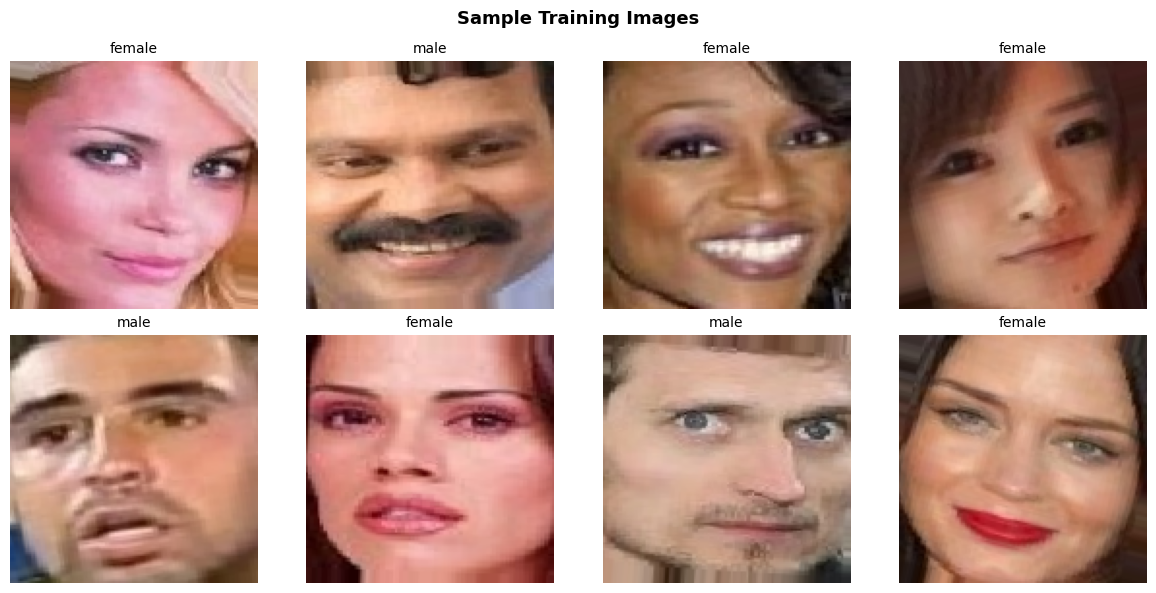

In [ ]:
# Visualise a sample batch
images, labels = next(train_gen)
class_names = list(train_gen.class_indices.keys())

fig, axes = plt.subplots(2, 4, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    ax.imshow(images[i])
    ax.set_title(class_names[int(labels[i])], fontsize=10)
    ax.axis('off')
plt.suptitle('Sample Training Images', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 4: Build a CNN from Scratch

In [ ]:
def build_cnn(input_shape=(128, 128, 3)):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Block 2
        layers.Conv2D(64, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Block 3
        layers.Conv2D(128, (3,3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(2,2),

        # Classifier head
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1, activation='sigmoid')  # binary output
    ], name='gender_cnn')
    return model

cnn_model = build_cnn()
cnn_model.summary()

Model: "gender_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,785 (432.75 KB)

 Trainable params: 110,337 (431.00 KB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=3, verbose=1)
]

history_cnn = cnn_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 241s 944ms/step - accuracy: 0.6430 - loss: 0.6431 - val_accuracy: 0.6139 - val_loss: 0.6515 - learning_rate: 0.0010
Epoch 2/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 263s 947ms/step - accuracy: 0.7049 - loss: 0.5769 - val_accuracy: 0.5736 - val_loss: 0.6941 - learning_rate: 0.0010
Epoch 3/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 257s 926ms/step - accuracy: 0.7464 - loss: 0.5167 - val_accuracy: 0.5181 - val_loss: 0.8800 - learning_rate: 0.0010
Epoch 4/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 236s 940ms/step - accuracy: 0.7913 - loss: 0.4565 - val_accuracy: 0.7692 - val_loss: 0.5072 - learning_rate: 0.0010
Epoch 5/5
251/251 ━━━━━━━━━━━━━━━━━━━━ 237s 945ms/step - accuracy: 0.8370 - loss: 0.3678 - val_accuracy: 0.6079 - val_loss: 0.8020 - learning_rate: 0.0010


## Step 5: Transfer Learning with MobileNetV2

In [ ]:
def build_transfer_model(input_shape=(128, 128, 3)):
    base = MobileNetV2(input_shape=input_shape, include_top=False, weights='imagenet')
    base.trainable = False  # Freeze base layers initially

    inputs = keras.Input(shape=input_shape)
    x = base(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)

    return keras.Model(inputs, outputs, name='mobilenetv2_gender')

transfer_model = build_transfer_model()
transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_gender"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
transfer_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_transfer = transfer_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=2,
    callbacks=callbacks
)

Epoch 1/2
251/251 ━━━━━━━━━━━━━━━━━━━━ 84s 314ms/step - accuracy: 0.8095 - loss: 0.4305 - val_accuracy: 0.8387 - val_loss: 0.3795 - learning_rate: 0.0010
Epoch 2/2
251/251 ━━━━━━━━━━━━━━━━━━━━ 77s 305ms/step - accuracy: 0.8615 - loss: 0.3445 - val_accuracy: 0.8548 - val_loss: 0.3349 - learning_rate: 0.0010


## Step 6: Plot Training Curves

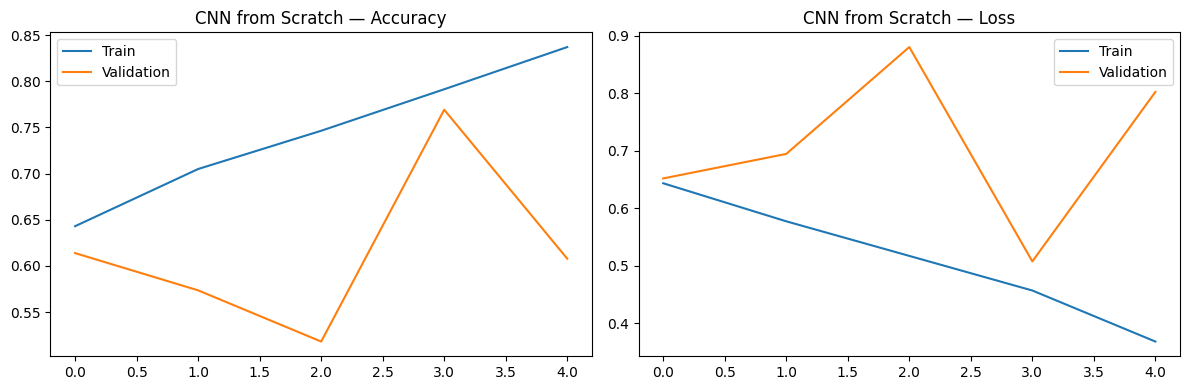

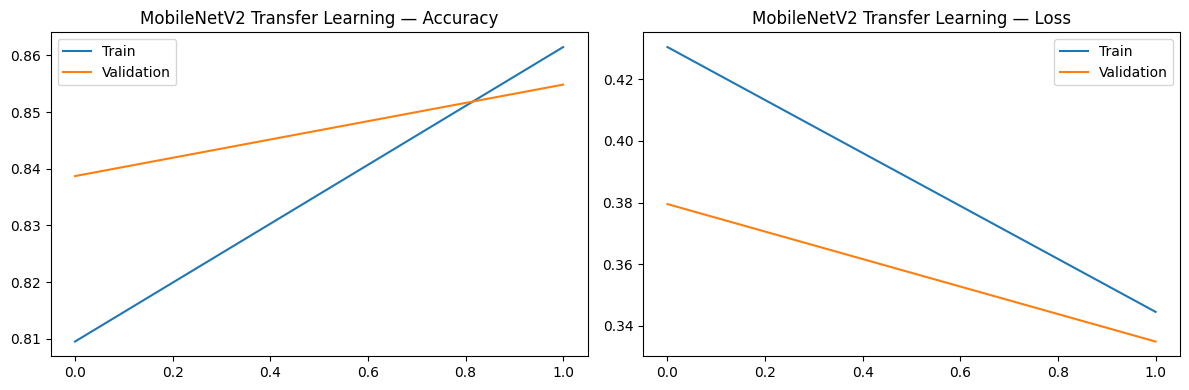

In [ ]:
def plot_history(history, title):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history.history['accuracy'], label='Train')
    ax1.plot(history.history['val_accuracy'], label='Validation')
    ax1.set_title(f'{title} — Accuracy')
    ax1.legend()
    ax2.plot(history.history['loss'], label='Train')
    ax2.plot(history.history['val_loss'], label='Validation')
    ax2.set_title(f'{title} — Loss')
    ax2.legend()
    plt.tight_layout()
    plt.show()

plot_history(history_cnn, 'CNN from Scratch')
plot_history(history_transfer, 'MobileNetV2 Transfer Learning')

## Step 7: Predict on a New Image

Saving Screenshot 2026-06-16 001518.png to Screenshot 2026-06-16 001518.png


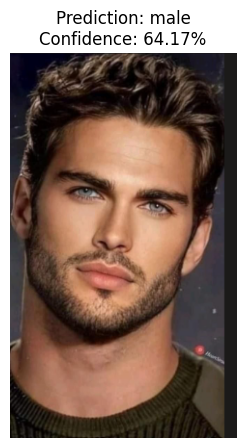

Raw model output: 0.6417
Predicted class: male
Confidence: 64.17%


In [ ]:
# Re-import in case 'files' was overwritten
from google.colab import files

from PIL import Image
import io
import numpy as np
import matplotlib.pyplot as plt

# Upload test image
uploaded_test = files.upload()

# Create index-to-class mapping
idx_to_class = {v: k for k, v in train_gen.class_indices.items()}

for fname, data in uploaded_test.items():

    # Load image
    img = Image.open(io.BytesIO(data)).convert('RGB')

    # Keep original for display
    display_img = img.copy()

    # Resize to model input size
    img = img.resize((128, 128))

    # Preprocess
    arr = np.array(img, dtype=np.float32) / 255.0
    arr = np.expand_dims(arr, axis=0)

    # Predict
    pred = transfer_model.predict(arr, verbose=0)[0][0]

    # Binary classification
    pred_class = 1 if pred >= 0.5 else 0
    label = idx_to_class[pred_class]

    confidence = pred if pred >= 0.5 else 1 - pred

    # Display result
    plt.figure(figsize=(5, 5))
    plt.imshow(display_img)
    plt.title(
        f"Prediction: {label}\nConfidence: {confidence*100:.2f}%"
    )
    plt.axis('off')
    plt.show()

    print(f"Raw model output: {pred:.4f}")
    print(f"Predicted class: {label}")
    print(f"Confidence: {confidence*100:.2f}%")